In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
data = pd.read_csv("data.csv")

In [42]:
print(data.head(10))
m = data.shape[0]
X = np.hstack((np.ones((m,1)), data.Hours.values.reshape(-1,1)))
y = np.array(data.Grades.values).reshape(-1,1)
theta = np.zeros((X.shape[1],1))



   Hours  Grades
0    0.5       8
1    0.6       9
2    0.7      10
3    0.8      11
4    0.9      12
5    1.0      14
6    1.1      15
7    1.2      16
8    1.3      17
9    1.4      18


In [43]:
num_iterations = 1500
learning_rate = 0.01
print(y.shape)

(204, 1)


In [44]:
def compute_cost(X, y, theta):
    #THIS FUNCTIONS COMPUTES THETA USING THE COST FUNCTI0N (MSE AKA MEAN SQUARED ERROR)
    n = y.shape[0]
    h = X.dot(theta)
    cost = (1/2*n) * np.sum(np.square(h-y))
    return cost

In [45]:
j = compute_cost(X, y, theta)
print("when initial theta = [0,0]\ncost computed = ", j)

when initial theta = [0,0]
cost computed =  82280442.0


In [46]:
def gradient_descent(X, y, theta, learning_rate, num_iterations):
    s = y.shape[0]
    j = np.zeros(shape=(num_iterations,1))

    for i in range(0, num_iterations):
        h = X.dot(theta)
        diff = h - y

        delta = (1/s) * X.T.dot(diff)
        theta = theta - learning_rate * delta
        j[i] = compute_cost(X, y, theta)

    return theta, j

In [47]:
theta, j = gradient_descent(X, y, theta, learning_rate, num_iterations)
print("theta computed from gradient descent = ", theta)

theta computed from gradient descent =  [[3.6438994 ]
 [9.95255085]]


In [48]:
def predict(hours, theta):
    hours = np.array(hours).reshape(-1,1)

    X_new = np.hstack((np.ones((hours.shape[0],1)),hours))

    predictions = X_new.dot(theta)
    return predictions

In [49]:
predictions = predict([9.25], theta)
print("predicted  grade of 9.25 hours of study = " ,predictions[0])

predicted  grade of 9.25 hours of study =  [95.7049948]


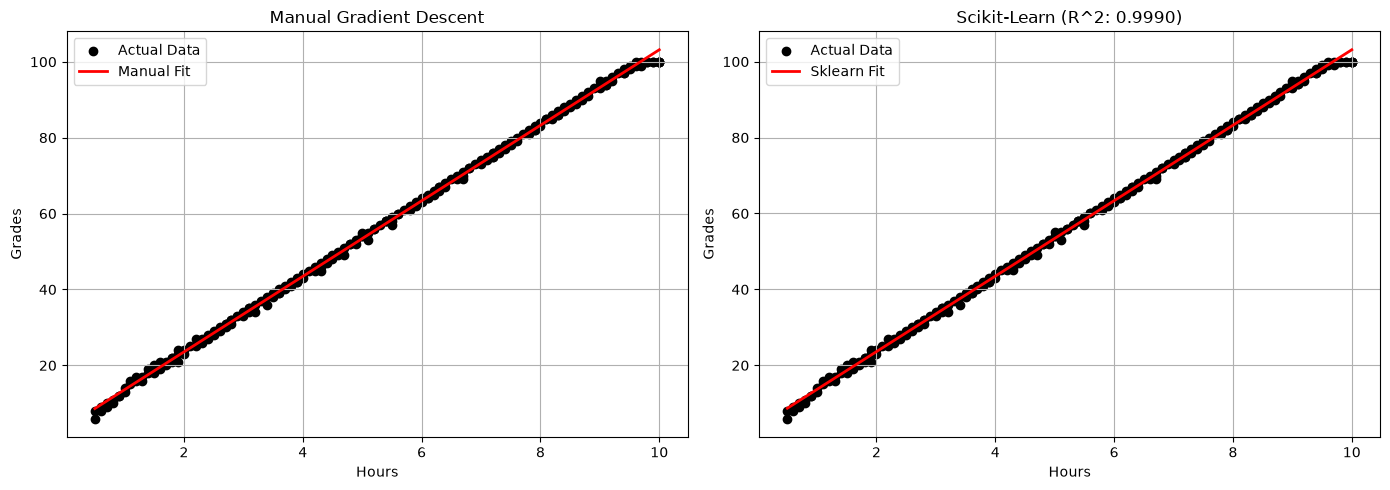


--- SCIKIT-LEARN RESULTS ---
Slope (Coefficient): 9.9387
Intercept (Bias):    3.7371
Accuracy (R^2 Score): 0.9990

Theta found by gradient descent: [[3.6438994 ]
 [9.95255085]]


In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(data['Hours'], data['Grades'], color='black', label='Actual Data')
ax1.plot(X[:, 1], X.dot(theta), color='red', linewidth=2, label='Manual Fit')
ax1.set_title("Manual Gradient Descent")
ax1.set_xlabel("Hours")
ax1.set_ylabel("Grades")
ax1.grid(True)
ax1.legend()

model = LinearRegression()
model.fit(X, y)
accuracy = model.score(X, y)

ax2.scatter(data['Hours'], data['Grades'], color='black', label='Actual Data')
ax2.plot(X[:, 1], model.predict(X), color='red', linewidth=2, label='Sklearn Fit')
ax2.set_title(f"Scikit-Learn (R^2: {accuracy:.4f})")
ax2.set_xlabel("Hours")
ax2.set_ylabel("Grades")
ax2.grid(True)
ax2.legend()

plt.tight_layout() 
plt.show()

slope = model.coef_[0][1] 
intercept = model.intercept_[0]
print("\n--- SCIKIT-LEARN RESULTS ---")
print(f"Slope (Coefficient): {slope:.4f}")
print(f"Intercept (Bias):    {intercept:.4f}")
print(f"Accuracy (R^2 Score): {accuracy:.4f}")
print('\nTheta found by gradient descent:',theta)